## Requirements

### Dependencies

### Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Feature Extraction Pipeline

In [ ]:
def extract_payload_length(info_string):
    """Extract payload length from Info column"""
    if pd.isna(info_string):
        return 0
    info_str = str(info_string)
    # Look for "Len=" in the Info field
    if "Len=" in info_str:
        try:
            # Extract the number after "Len="
            len_idx = info_str.find("Len=")
            len_str = info_str[len_idx+4:].split()[0]
            return int(len_str)
        except:
            return 0
    return 0


def extract_features(df_session):
    """
    Extract network traffic features from a session dataframe.
    
    Parameters:
    df_session: DataFrame with columns 'Time' and 'Length'
    
    Returns:
    Dictionary containing all extracted features
    """
    features = {}
    
    # 1. Packet count
    features['packet_count'] = len(df_session)
    
    # 2. Total length
    features['total_length'] = df_session['Length'].sum()
    
    # Packet intervals
    if len(df_session) > 1:
        time_diffs = df_session['Time'].diff().dropna().values
        features['avg_packet_interval'] = time_diffs.mean()
        features['max_packet_interval'] = time_diffs.max()
        features['min_packet_interval'] = time_diffs.min()
    else:
        features['avg_packet_interval'] = 0
        features['max_packet_interval'] = 0
        features['min_packet_interval'] = 0
    
    # Packet length statistics
    features['avg_packet_length'] = df_session['Length'].mean()
    features['max_packet_length'] = df_session['Length'].max()
    features['min_packet_length'] = df_session['Length'].min()
    
    # Most common packet length
    try:
        features['most_common_packet_length'] = mode(df_session['Length'].values)
    except StatisticsError:
        # If there's no mode (all unique), use 0 or NaN
        features['most_common_packet_length'] = np.nan
    
    # Payload and header statistics
    df_session['payload_length'] = df_session['Info'].apply(extract_payload_length)
    features['avg_payload_length'] = df_session['payload_length'].mean()
    
    df_session['header_length'] = df_session['Length'] - df_session['payload_length']
    features['avg_header_length'] = df_session['header_length'].mean()
    
    return features


def load_and_process_sessions(data_dir='data'):
    """
    Load all network session CSV files matching pattern networkname_number.csv
    and extract features for each session.
    
    Parameters:
    data_dir: Directory containing the CSV files
    
    Returns:
    DataFrame with one row per session and columns for each feature
    """
    data_path = Path(data_dir)
    csv_files = sorted(data_path.glob('*_*.csv'))
    
    all_features = []
    
    for csv_file in csv_files:
        try:
            # Load the session
            df = pd.read_csv(csv_file)
            
            # Extract network name and session number from filename
            filename = csv_file.stem  # removes .csv extension
            parts = filename.rsplit('_', 1)  # split from the right on last _
            if len(parts) == 2:
                network_name, session_num = parts
            else:
                network_name = filename
                session_num = None
            
            # Convert Time column to numeric and sort by time
            df['Time'] = pd.to_numeric(df['Time'])
            df = df.sort_values('Time').reset_index(drop=True)
            
            # Extract features
            features = extract_features(df)
            features['network'] = network_name
            features['session'] = session_num
            
            all_features.append(features)
            print(f"Processed: {csv_file.name}")
            
        except Exception as e:
            print(f"Error processing {csv_file.name}: {e}")
    
    # Create DataFrame from all features
    features_df = pd.DataFrame(all_features)
    return features_df


# Load and process all sessions
df_features = load_and_process_sessions('data')

#### Split data into train, test, val and balance classes

In [31]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp)

op = RandomUnderSampler(random_state=42)
X_train, y_train = op.fit_resample(X_train, y_train)

#### Scale data

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## Selected Models

This machine learning problem being binary classification, the selected preliminary models are Logistic Regression, Perceptron, KNN, SVM, Decision Trees, and Random Forest

#### Libraries

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#### Logistic Regression

In [35]:
#Training Logistic Regression

LR = LogisticRegression(max_iter=50)
LR.fit(X_train_scaled, y_train)

C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=50)

#### Perceptron

In [36]:
#Train perceptron model

perceptron = Perceptron(fit_intercept=True, shuffle=True, max_iter=50)
perceptron.fit(X_train_scaled, y_train)

C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Perceptron(max_iter=50)

In [37]:
weights = perceptron.coef_
b = perceptron.intercept_[0]
print("Weights:", weights)
print("Bias (b):", b)
print("Number of passes (n_iter_):", perceptron.n_iter_)

Weights: [[ 1.03471659e+01  1.55759011e+00  4.14891076e+00 -9.91317279e-01
   1.39626756e+00 -5.74466688e-01  5.74466688e-01  1.50962577e+00
  -1.50962577e+00  4.20675200e+00  0.00000000e+00  7.27104491e-03
  -9.80830301e-01 -8.24957911e+00 -3.12592843e+00  3.12592843e+00
   1.89054560e+00 -2.85945285e+00  1.46136690e+00]]
Bias (b): -3.0
Number of passes (n_iter_): 14


#### SVM

In [38]:
#Using features avg_glucose_level and bmi

X_svm_temp, X_svm_test, y_svm_temp, y_svm_test = train_test_split(X[['avg_glucose_level','bmi']], y, test_size=0.15, random_state=42, stratify=y)
X_svm_train, X_svm_val, y_svm_train, y_svm_val = train_test_split(X_svm_temp, y_svm_temp, test_size=0.15, random_state=42, stratify=y_svm_temp)

os = RandomUnderSampler(random_state=42)
X_svm_train, y_svm_train = os.fit_resample(X_svm_train, y_svm_train)

In [39]:
scaler_svm = StandardScaler()

X_svm_train_scaled = scaler_svm.fit_transform(X_svm_train)
X_svm_val_scaled = scaler_svm.transform(X_svm_val)
X_svm_test_scaled = scaler_svm.transform(X_svm_test)

In [ ]:
#Hyperparameters for Linear SVM

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
val_accuracies = []

for C in C_values:
    svm = LinearSVC(C=C, loss='hinge', max_iter=1000, class_weight='balanced')
    svm.fit(X_svm_train, y_svm_train)
    y_val_pred = svm.predict(X_svm_val)
    val_acc = f1_score(y_svm_val, y_val_pred)
    val_accuracies.append(val_acc)
    print(f"C={C} - Validation Accuracy: {val_acc:.3f}")

best_C = C_values[np.argmax(val_accuracies)]
print(f"Best C: {best_C}")

C=0.001 - Validation Accuracy: 0.135
C=0.01 - Validation Accuracy: 0.124
C=0.1 - Validation Accuracy: 0.000
C=1 - Validation Accuracy: 0.108
C=10 - Validation Accuracy: 0.000
C=100 - Validation Accuracy: 0.115
C=1000 - Validation Accuracy: 0.000
Best C: 0.001


C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\lynbl\AppData\Roaming\Python\Python312\

In [53]:
#Train best Linear SVM model
SVM = LinearSVC(C=best_C, loss='hinge', max_iter=1000, class_weight='balanced')
SVM.fit(X_svm_train, y_train)

C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=0.001, class_weight='balanced', loss='hinge')

#### KNN

In [54]:
#Find best hyperparameter for KNN

k_vals = range(1,31)
val_scores = []

for k in k_vals:
    KNN = KNeighborsClassifier(n_neighbors=k)
    KNN.fit(X_svm_train_scaled, y_svm_train)
    y_pred_val = KNN.predict(X_svm_val_scaled)
    val_acc = f1_score(y_svm_val, y_pred_val)
    val_scores.append(val_acc)
    print(f"k={k} - Validation Accuracy: {val_acc:.3f}")

best_k = k_vals[np.argmax(val_scores)]
print(f"\nBest k based on validation data: {best_k}")

C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was

k=1 - Validation Accuracy: 0.096
k=2 - Validation Accuracy: 0.093
k=3 - Validation Accuracy: 0.114
k=4 - Validation Accuracy: 0.120
k=5 - Validation Accuracy: 0.100
k=6 - Validation Accuracy: 0.110
k=7 - Validation Accuracy: 0.098
k=8 - Validation Accuracy: 0.122
k=9 - Validation Accuracy: 0.099
k=10 - Validation Accuracy: 0.130
k=11 - Validation Accuracy: 0.109
k=12 - Validation Accuracy: 0.133
k=13 - Validation Accuracy: 0.108
k=14 - Validation Accuracy: 0.125
k=15 - Validation Accuracy: 0.116
k=16 - Validation Accuracy: 0.112


C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was

k=17 - Validation Accuracy: 0.098
k=18 - Validation Accuracy: 0.113
k=19 - Validation Accuracy: 0.091
k=20 - Validation Accuracy: 0.115
k=21 - Validation Accuracy: 0.095
k=22 - Validation Accuracy: 0.115
k=23 - Validation Accuracy: 0.095
k=24 - Validation Accuracy: 0.117
k=25 - Validation Accuracy: 0.108
k=26 - Validation Accuracy: 0.127


C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was

k=27 - Validation Accuracy: 0.110
k=28 - Validation Accuracy: 0.136
k=29 - Validation Accuracy: 0.121
k=30 - Validation Accuracy: 0.137

Best k based on validation data: 30


C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [55]:
#Build KNN with optimized hyperparameter

KNN = KNeighborsClassifier(n_neighbors=best_k)
KNN.fit(X_svm_train_scaled, y_svm_train)

C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=30)

#### Decision Tree

In [91]:
#Validation testing to find best depth for Decision Tree

depths = [2, 4, 6, 8, None]
dt_scores = []

for depth in depths:
    DT = DecisionTreeClassifier(max_depth=depth, random_state=42)
    DT.fit(X_train_scaled, y_train)
    y_pred_val = DT.predict(X_val_scaled)
    f1 = f1_score(y_val, y_pred_val)
    dt_scores.append(f1)
    print(f"max_depth={depth} → F1 Score: {f1:.3f}")

best_depth = depths[np.argmax(dt_scores)]
print(f"Best depth (by validation): {best_depth}")

max_depth=2 → F1 Score: 0.244
max_depth=4 → F1 Score: 0.222
max_depth=6 → F1 Score: 0.181
max_depth=8 → F1 Score: 0.179
max_depth=None → F1 Score: 0.162
Best depth (by validation): 2


In [92]:
#Training Decision Tree with best depth

tree_clf = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree_clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

#### Random Forest

In [93]:
#Validation to find best hyperparameters for Decision Tree

candidates = [5, 10, 50, 100, 500]
rf_scores = []

for n_estimator in candidates:
    classifier = RandomForestClassifier(n_estimator, max_depth=None, random_state=42)
    classifier.fit(X_train_scaled, y_train)
    y_pred_val = classifier.predict(X_val_scaled)
    f1 = f1_score(y_val, y_pred_val)
    rf_scores.append(f1)
    print(f"n_estimator {n_estimator} → F1 Score: {f1:.3f}")

best_n_estimator = candidates[np.argmax(rf_scores)]
print(f"Best n_estimator (by validation): {best_n_estimator}")

C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed whe

n_estimator 5 → F1 Score: 0.151
n_estimator 10 → F1 Score: 0.178
n_estimator 50 → F1 Score: 0.212
n_estimator 100 → F1 Score: 0.211


C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


n_estimator 500 → F1 Score: 0.227
Best n_estimator (by validation): 500


In [94]:
#Random Forest with best hyperparameter
RF = RandomForestClassifier(n_estimators=best_n_estimator, max_depth=None, random_state=42)
RF.fit(X_train_scaled, y_train)

C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(n_estimators=500, random_state=42)

## Model Evaluation

#### Libraries

In [48]:
from sklearn.metrics import f1_score

#### Evaluate Models

Assess each model's performance on validation data using your chosen metrics (f1 score)

In [95]:
# Setting up result tables

models = {
    "Logistic Regression": LR,
    "Perceptron": perceptron,
    "Linear SVM": SVM,
    "K-Nearest Neighbors": KNN,
    "Decision Tree": DT,
    "Random Forest": RF
}

training_accuracies = {}
validation_accuracies = {}

for model_name, model in models.items():

    if model_name in ["Linear SVM", "K-Nearest Neighbors"]:
        y_pred_train = model.predict(X_svm_train_scaled)
        y_pred_val = model.predict(X_svm_val_scaled)
        train_acc = f1_score(y_svm_train, y_pred_train, average='macro')
        val_acc = f1_score(y_svm_val, y_pred_val, average='macro')

        training_accuracies[model_name] = train_acc
        validation_accuracies[model_name] = val_acc

        print(f"{model_name} - Train F1 Score: {train_acc:.3f}, Validation F1 Score: {val_acc:.3f}")
        continue

    y_pred_train = model.predict(X_train_scaled)
    y_pred_val = model.predict(X_val_scaled)
    train_acc = f1_score(y_train, y_pred_train, average='macro')
    val_acc = f1_score(y_val, y_pred_val, average='macro')

    training_accuracies[model_name] = train_acc
    validation_accuracies[model_name] = val_acc

    print(f"{model_name} - Train F1 Score: {train_acc:.3f}, Validation F1 Score: {val_acc:.3f}")

Logistic Regression - Train F1 Score: 0.787, Validation F1 Score: 0.534
Perceptron - Train F1 Score: 0.691, Validation F1 Score: 0.519
Linear SVM - Train F1 Score: 0.512, Validation F1 Score: 0.404
K-Nearest Neighbors - Train F1 Score: 0.660, Validation F1 Score: 0.486
Decision Tree - Train F1 Score: 1.000, Validation F1 Score: 0.466
Random Forest - Train F1 Score: 1.000, Validation F1 Score: 0.515


C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
C:\Users\lynbl\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


In [96]:
#Training data result table

training_results = pd.DataFrame.from_dict(training_accuracies, orient='index', columns=['Training F1 Score'])
training_results

,Training F1 Score
Logistic Regression,0.787032
Perceptron,0.691071
Linear SVM,0.511844
K-Nearest Neighbors,0.660465
Decision Tree,1.000000
Random Forest,1.000000


In [97]:
#Validation data result table

validation_results = pd.DataFrame.from_dict(validation_accuracies, orient='index', columns=['Validation F1 Score'])
validation_results

,Validation F1 Score
Logistic Regression,0.533571
Perceptron,0.519377
Linear SVM,0.404254
K-Nearest Neighbors,0.486032
Decision Tree,0.465510
Random Forest,0.514893


In [98]:
#Top 3 models

top_3_models = validation_results.sort_values(by='Validation F1 Score', ascending=False).head(3)
top_3_models

,Validation F1 Score
Logistic Regression,0.533571
Perceptron,0.519377
Random Forest,0.514893


In [99]:
#Evaluate top 3 models on test data

test_accuracies = {}
test_predictions = {}
test_scores = {}

for model_name in top_3_models.index:

    if model_name in ["Linear SVM", "K-Nearest Neighbors"]:
        model = models[model_name]
        y_pred_test = model.predict(X_svm_test_scaled)
        test_acc = accuracy_score(y_svm_test, y_pred_test)
        test_f1 = f1_score(y_svm_test, y_pred_test, average='macro')
        test_accuracies[model_name] = test_acc
        test_scores[model_name] = test_f1
        test_predictions[model_name] = y_pred_test
        print(f"{model_name} - Test Accuracy: {test_acc:.3f}, Test F1 Score: {test_f1:.3f}")
        continue

    model = models[model_name]
    y_pred_test = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test, average='macro')
    test_accuracies[model_name] = test_acc
    test_scores[model_name] = test_f1
    test_predictions[model_name] = y_pred_test
    print(f"{model_name} - Test Accuracy: {test_acc:.3f}, Test F1 Score: {test_f1:.3f}")

Logistic Regression - Test Accuracy: 0.701, Test F1 Score: 0.515
Perceptron - Test Accuracy: 0.705, Test F1 Score: 0.510
Random Forest - Test Accuracy: 0.675, Test F1 Score: 0.499


In [100]:
#Table of test accuracies for top 3 models

test_results1 = pd.DataFrame.from_dict(test_accuracies, orient='index', columns=['Test Accuracy'])
test_results2 = pd.DataFrame.from_dict(test_scores, orient='index', columns=['Test F1 Score'])
test_results = pd.concat([test_results1, test_results2], axis=1)
test_results

,Test Accuracy,Test F1 Score
Logistic Regression,0.700935,0.515464
Perceptron,0.704673,0.510414
Random Forest,0.674766,0.498805


## Model Predictions

### Libraries

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Prediction Visualizations

#### Logistic Regression

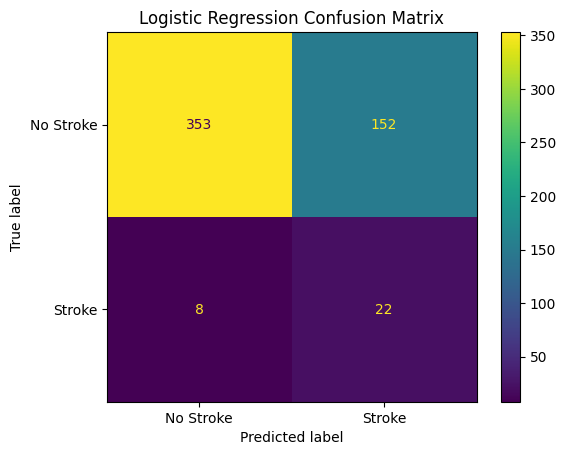

In [74]:
#Logistic Regression Confusion Matrix

lr_cm = confusion_matrix(y_test, test_predictions['Logistic Regression'])
disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=["No Stroke", "Stroke"])
disp.plot(cmap='viridis', values_format='d')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

#### Perceptron

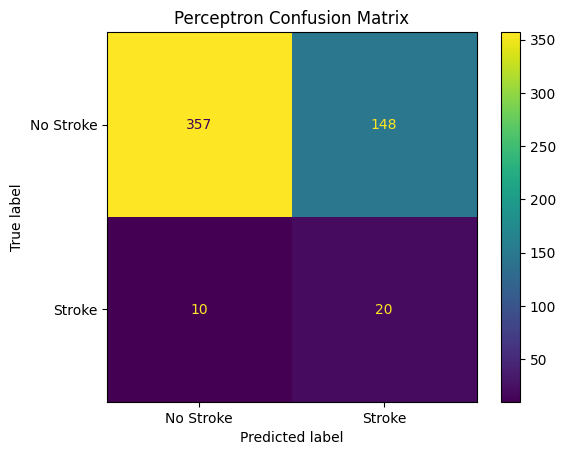

In [75]:
#Perceptron Confusion matrix

perceptron_cm = confusion_matrix(y_test, test_predictions['Perceptron'])
disp = ConfusionMatrixDisplay(confusion_matrix=perceptron_cm, display_labels=["No Stroke", "Stroke"])
disp.plot(cmap='viridis', values_format='d')
plt.title("Perceptron Confusion Matrix")
plt.show()

#### Random Forest

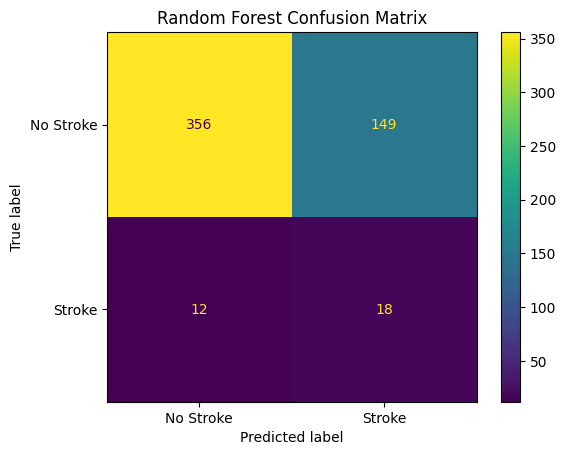

In [77]:
# Visualization of Random Forest Confusion Matrix

rf_cm = confusion_matrix(y_test, test_predictions['Random Forest'])
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=["No Stroke", "Stroke"])
disp.plot(cmap='viridis', values_format='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

### Hyperparameters' Visualizations

#### SVM Hyperparameters

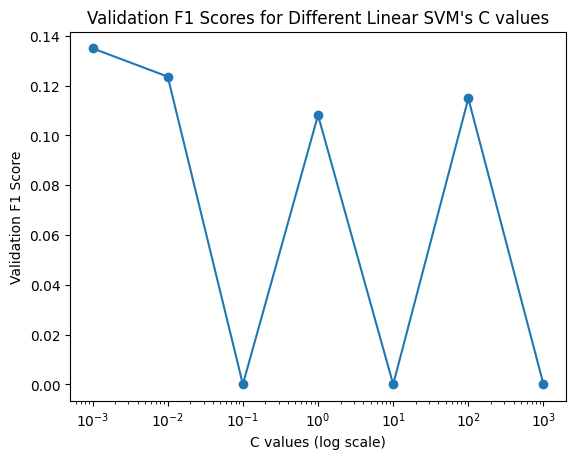

In [84]:
# Graph of validation f1 scores for different SVM hyperparameters

plt.plot(C_values, val_accuracies, marker='o')
plt.xscale('log')
plt.xlabel('C values (log scale)')
plt.ylabel('Validation F1 Score')
plt.title('Validation F1 Scores for Different Linear SVM\'s C values')
plt.show()

#### KNN Hyperparameters

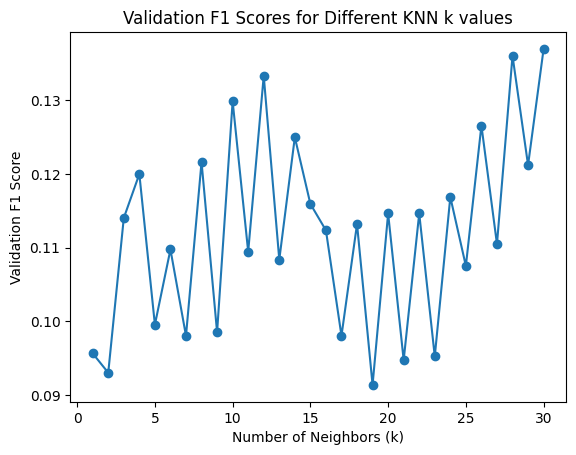

In [85]:
# Graph of validation f1 scores for KNN k hyperparameter

plt.plot(k_vals, val_scores, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation F1 Score')
plt.title('Validation F1 Scores for Different KNN k values')
plt.show()

#### Decision Tree Hyperparameters

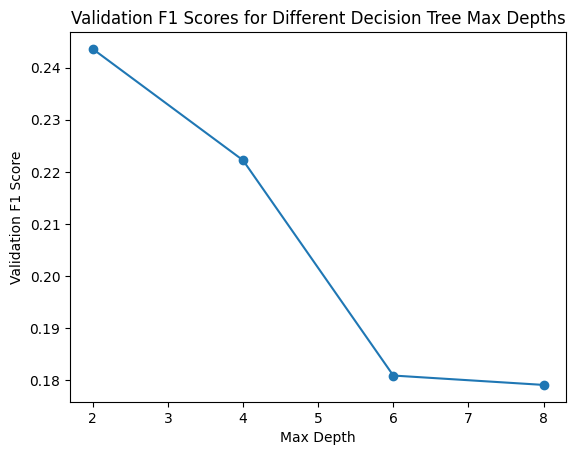

In [101]:
# Graph of validation f1 scores for Decision Tree max_depth hyperparameter

plt.plot(depths, dt_scores, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Validation F1 Score')
plt.title('Validation F1 Scores for Different Decision Tree Max Depths')
plt.show()

#### Random Forest Hyperparameters

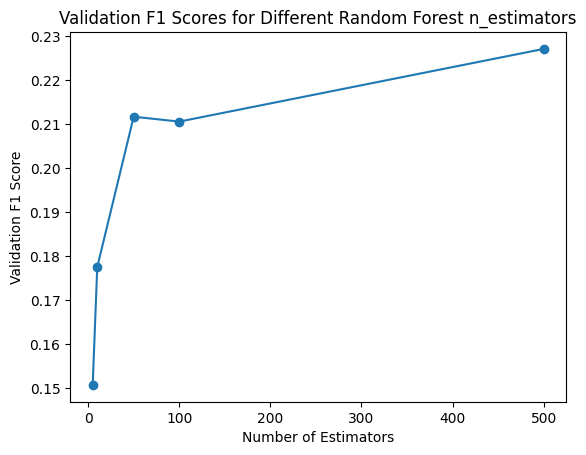

In [102]:
# Graph of validation f1 scores for Random Forest n_estimators hyperparameter

plt.plot(candidates, rf_scores, marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Validation F1 Score')
plt.title('Validation F1 Scores for Different Random Forest n_estimators')
plt.show()

## Feature Summary

In [ ]:
df_features.head(10)

In [ ]:
print("Dataset shape:", df_features.shape)
print("\nFeatures extracted:")
print(df_features.dtypes)